<a href="https://colab.research.google.com/github/PatricioOnRails/ML_fundamentals_with_IrisDataset/blob/main/ML_fundamentals_with_the_IrisDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

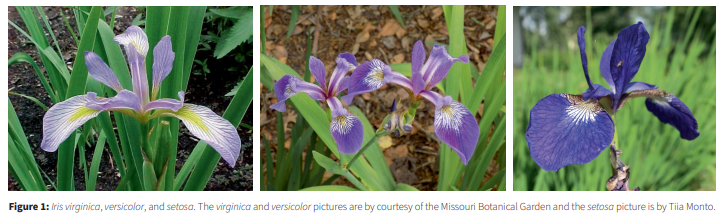

### Introduction to the Iris Dataset and Fisher's Linear Discriminant Analysis

The Iris dataset is one of the most famous datasets in the history of statistics and machine learning. It was originally introduced by the British statistician and biologist Ronald A. Fisher to demonstrate how a combination of multiple continuous measurements could be used to mathematically distinguish between different biological groups.

"The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems (https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1469-1809.1936.tb02137.x), and can also be found on the UCI Machine Learning Repository (https://archive.ics.uci.edu/)."

---

### Summary of the Paper: *The Use of Multiple Measurements in Taxonomic Problems*

Fisher's 1936 paper is a foundational text that bridges the gap between evolutionary biology (taxonomy) and multivariate statistics, introducing concepts that laid the groundwork for modern classification algorithms.

#### 1. The Core Objective: Discriminant Functions
Before Fisher's work, statisticians lacked a clear method to find a single statistic to differentiate two or more populations using multiple features simultaneously. Fisher introduced the **Linear Discriminant Function**, which finds a linear combination of features ($X_1, X_2, \dots, X_n$) that maximizes the variation *between* the groups relative to the variation *within* the groups. This maximizes the statistical distance between classes, ensuring the cleanest separation possible.

#### 2. The Iris Botanical Application
To rigorously test his new mathematical theory, Fisher utilized data collected by the botanist Edgar Anderson on three closely related flower species on the Gaspé Peninsula: *Iris setosa*, *Iris versicolor*, and *Iris virginica*.
* For 50 flowers of each species, four distinct morphological features were measured: **sepal length**, **sepal width**, **petal length**, and **petal width**.
* Fisher demonstrated that *Iris setosa* could be linearly separated with absolute precision from the other two species based on these features.
* Separating *Iris versicolor* from *Iris virginica* proved more complex due to their overlapping characteristics, providing a perfect real-world benchmark for testing the boundaries of his linear discriminant technique.

#### 3. Phylogenetic Analysis and Genetic Linkage
Beyond mere classification, the latter part of the paper investigates the genetic and evolutionary relationships between these species. Fisher applied quadratic multi-variable analysis to analyze if *Iris versicolor* could be a hybrid polyploid offspring of *Iris setosa* and *Iris virginica*. By examining the deviations in the measurements, he provided a statistical framework to test biological hypotheses regarding evolutionary lineage.

---

#### Bibliographic Reference
FISHER, R.A. (1936), THE USE OF MULTIPLE MEASUREMENTS IN TAXONOMIC PROBLEMS. *Annals of Eugenics*, 7: 179-188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x

---

### Header Image Reference & Historical Context

The header image utilized in this notebook is sourced from a modern reassessment of the Iris dataset's origins, which investigates how Edgar Anderson originally collected the samples and how the data found its way into Fisher's hands.

* **Artigo:** *The Iris Data Set: In Search of the Source of Virginica*
* **Autores:** Antony Unwin & Kim Kleinman
* **Publicação:** *Significance*, Volume 18, Issue 6, December 2021, Pages 26–29.
* **Link:** [https://doi.org/10.1111/1740-9713.01589](https://doi.org/10.1111/1740-9713.01589)

---

#### Full Bibliographic Citation (APA Style)
Unwin, A., & Kleinman, K. (2021). The Iris Data Set: In Search of the Source of Virginica. *Significance*, 18(6), 26–29. https://doi.org/10.1111/1740-9713.01589

### Notebook Setup

In [1]:
# Make sure that we are in the correct virtual enviroment
!which python

/usr/local/bin/python


In [2]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# autoreload helps keep your code changes in external files immediately updated in the notebook, and
# %load_ext autoreload
# %autoreload 2
# ensures that your data visualizations are seamlessly integrated into the notebook's output.
%matplotlib inline

In [3]:
# Standard imports
import os

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports

In [4]:
sns.set()

### Load data
Let's load the Iris flower dataset using scikit-learn's bult-in datasets.

In [5]:
from sklearn import datasets

iris = datasets.load_iris()

In [6]:
print(iris.DESCR) # View documentation

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
print('Iris Dataset Overview:') # Prints a general header for the overview
print(f'Data shape: {iris.data.shape}') # Prints the shape (dimensions) of the dataset's features
print(f'First 5 rows of data:\n{iris.data[:5]}') # Prints the first 5 rows of the feature data
print(f'Feature Names: {iris.feature_names}') # Prints the names of the features (e.g., sepal length, petal width)
print(f'Target shape: {iris.target.shape}') # Prints the shape (dimensions) of the dataset's target labels
print(f'Target values: {iris.target}') # Prints the target (species) values as numerical labels
print(f'Target Names: {iris.target_names}') # Prints the actual names corresponding to the numerical target labels (e.g., setosa, versicolor)

Iris Dataset Overview:
Data shape: (150, 4)
First 5 rows of data:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target shape: (150,)
Target values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Target Names: ['setosa' 'versicolor' 'virginica']



### Problem Statement

The objective of this analysis is to develop a **multiclass classification model** capable of predicting the species of an iris flower based on its morphological characteristics. Specifically, four numerical features are used as predictor variables:

- **Sepal length**
- **Sepal width**
- **Petal length**
- **Petal width**

The target variable corresponds to the flower species, which can belong to one of the following classes:

- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Therefore, this task is formulated as a **supervised learning problem**, where the goal is to learn a mapping between the input features and the corresponding flower species. Given a set of measurements describing a flower, the model should accurately assign it to one of the three classes.

### Mathematical Formulation

Let

\[
X = \{x_1, x_2, x_3, x_4\}
\]

where:

- \(x_1\): sepal length,
- \(x_2\): sepal width,
- \(x_3\): petal length,
- \(x_4\): petal width.

The objective is to learn a function

\[
f : X --> Y
\]

where

\[
Y ∈ {Setosa, Versicolor, Virginica}
\]

such that the model can accurately predict the species of an iris flower based on its observed features.

> **Problem Type:** Supervised Learning – Multiclass Classification.

### Create a pandas DataFrame

In [8]:
# Creates a pandas DataFrame.
# It uses the iris.data (which contains the numerical feature values) as the data source and
# iris.feature_names (which are the names of the features like 'sepal length (cm)') as the column headers for the DataFrame.
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adds the 'target' column to the DataFrame, which contains the numerical species labels.
df['target'] = iris.target

# Displays the DataFrame. In Colab, the last variable in a cell is automatically displayed.
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Basics descriptive statistics

In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### EDA - Exploratory Data Analisys * Pairplots

Generating a comprehensive pairplot for EDA, including the 'target' column. This might take a moment...


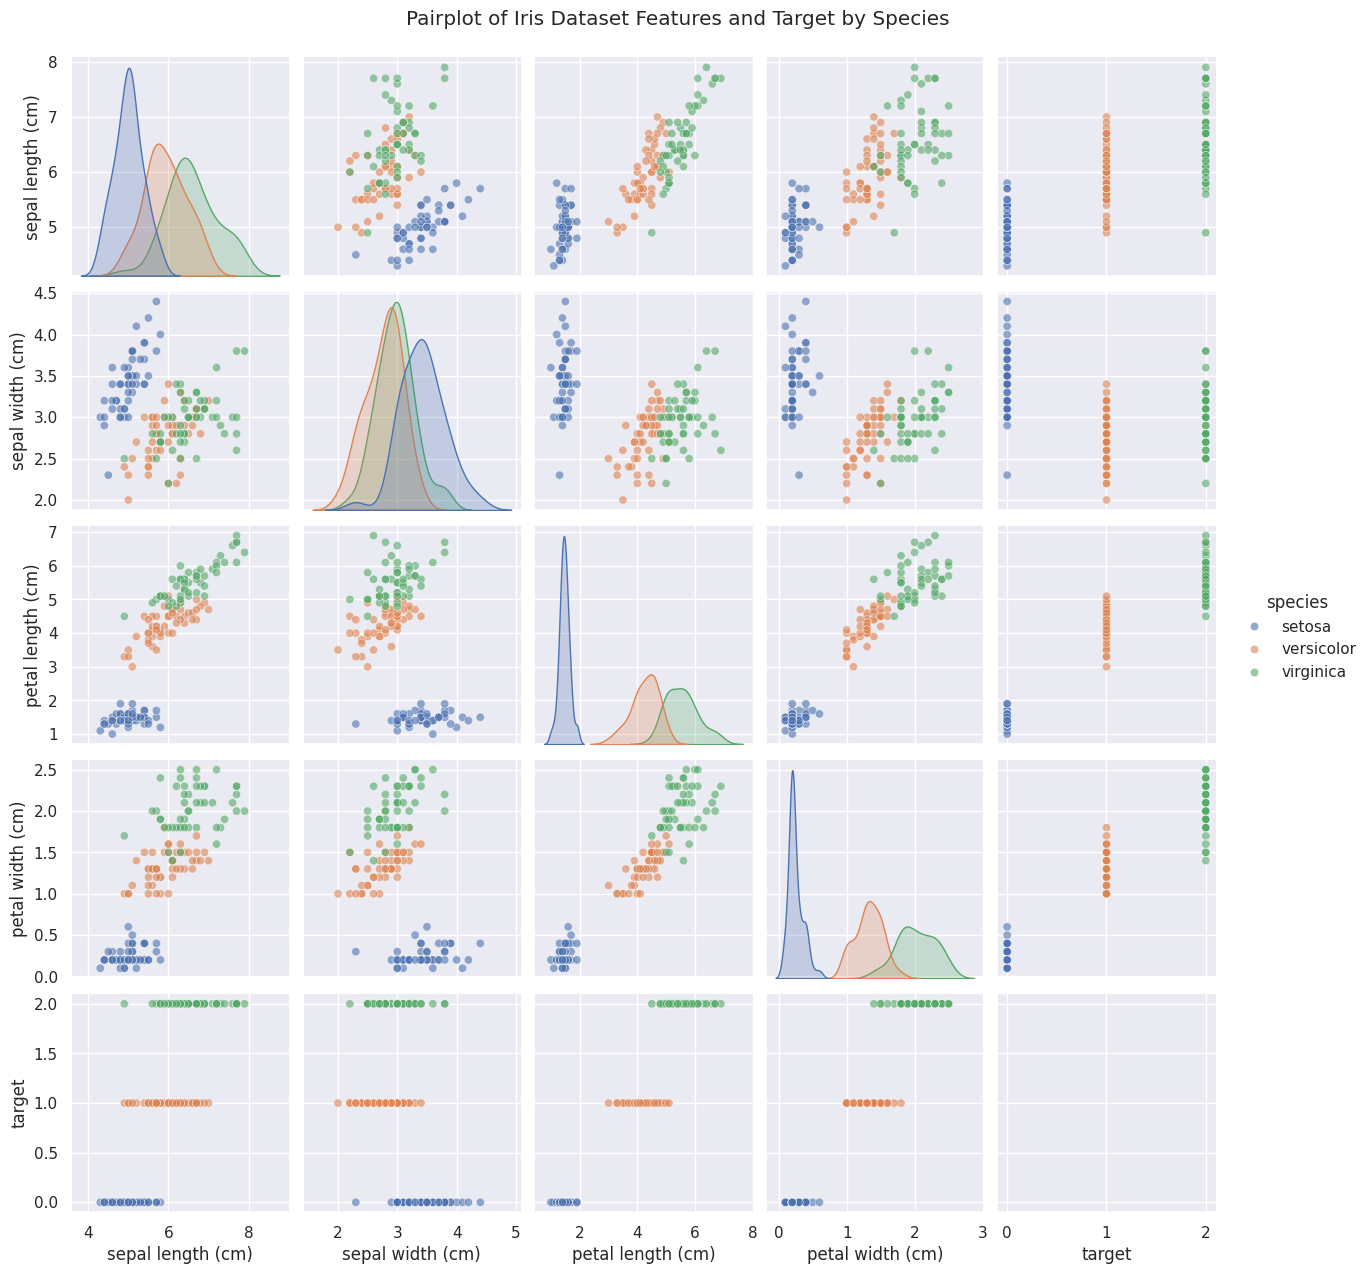

In [10]:
# Ensure the 'species' column is available for coloring the pairplot.
# This maps the numerical target (0, 1, 2) to their respective names ('setosa', 'versicolor', 'virginica').
# This step is often done once, but included here for completeness and clarity in the context of pairplot.
if 'species' not in df.columns:
    df['species'] = df['target'].map(lambda x: iris.target_names[x])

# Create a comprehensive pairplot for Exploratory Data Analysis (EDA).
# 'df' is our DataFrame containing features and the target. By passing the full 'df',
# the 'target' column will now be included in the grid of plots as a variable itself.
# 'hue="species"' colors the points and distributions based on the 'species' column,
# which helps in visualizing the separation and overlap between different iris types.
# 'diag_kind="kde"' plots a Kernel Density Estimate on the diagonal for each variable,
# showing the distribution of each feature (and now also 'target') for each species.
# 'plot_kws={'alpha': 0.6}' sets the transparency of the scatter plot points to improve readability
# where points might overlap.
print("Generating a comprehensive pairplot for EDA, including the 'target' column. This might take a moment...")
sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})

# Set a title for the entire figure to describe the visualization.
plt.suptitle('Pairplot of Iris Dataset Features and Target by Species', y=1.02) # Adjust 'y' to prevent overlap with subplots

# Display the generated pairplot.
plt.show()

### Train test split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Divide the main dataframe into 80% for training and 20% for testing; random_state ensures reproducibility.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [13]:
print(df_train.shape)
print(df_test.shape)

(120, 6)
(30, 6)


In [14]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
22,4.6,3.6,1.0,0.2,0,setosa
15,5.7,4.4,1.5,0.4,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor
11,4.8,3.4,1.6,0.2,0,setosa
42,4.4,3.2,1.3,0.2,0,setosa


### Prepare our data for modeling
Splitting the data back out into plain NumPy arrays

In [15]:
x_train = df_train.drop(['target', 'species'], axis=1).values
y_train = df_train['target'].values

x_test = df_test.drop(['target', 'species'], axis=1).values
y_test = df_test['target'].values

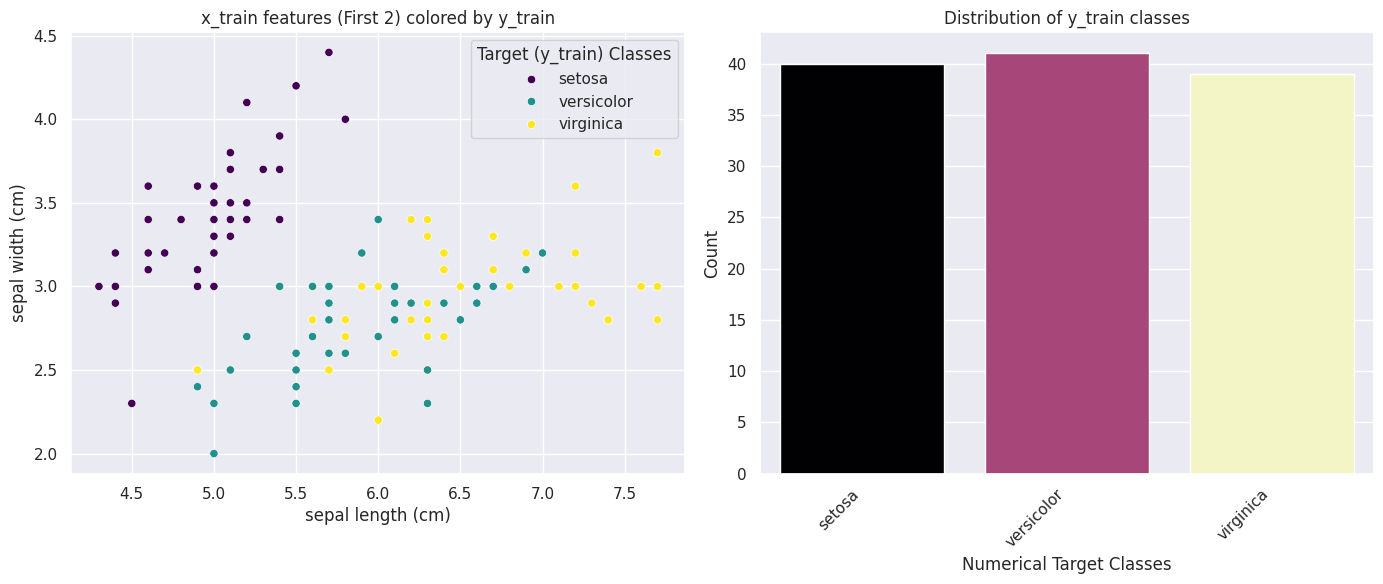

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Subplot: x_train (features) colored by y_train (target) ---
# Using the first two features of x_train for visualization. You can change these indices if needed.
sns.scatterplot(x=x_train[:, 0], y=x_train[:, 1], hue=y_train, palette='viridis', ax=axes[0])
axes[0].set_title('x_train features (First 2) colored by y_train')
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])

# Create a custom legend for target names
handles, labels = axes[0].get_legend_handles_labels()
class_labels = [iris.target_names[int(label)] for label in labels]
axes[0].legend(handles=handles, labels=class_labels, title='Target (y_train) Classes')

# --- Right Subplot: Distribution of y_train classes ---
sns.countplot(x=y_train, hue=y_train, palette='magma', ax=axes[1], legend=False) # Add hue and set legend=False to address FutureWarning
axes[1].set_title('Distribution of y_train classes')
axes[1].set_xlabel('Numerical Target Classes')
axes[1].set_ylabel('Count')

# Map numerical target labels to their actual names for better readability on the x-axis
axes[1].set_xticks(np.unique(y_train))
axes[1].set_xticklabels([iris.target_names[i] for i in np.unique(y_train)], rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Plot a PCA representation
Let’s apply a Principal Component Analysis (PCA) to the iris dataset and then plot the irises across the first three PCA dimensions. This will allow us to better differentiate between the three types!

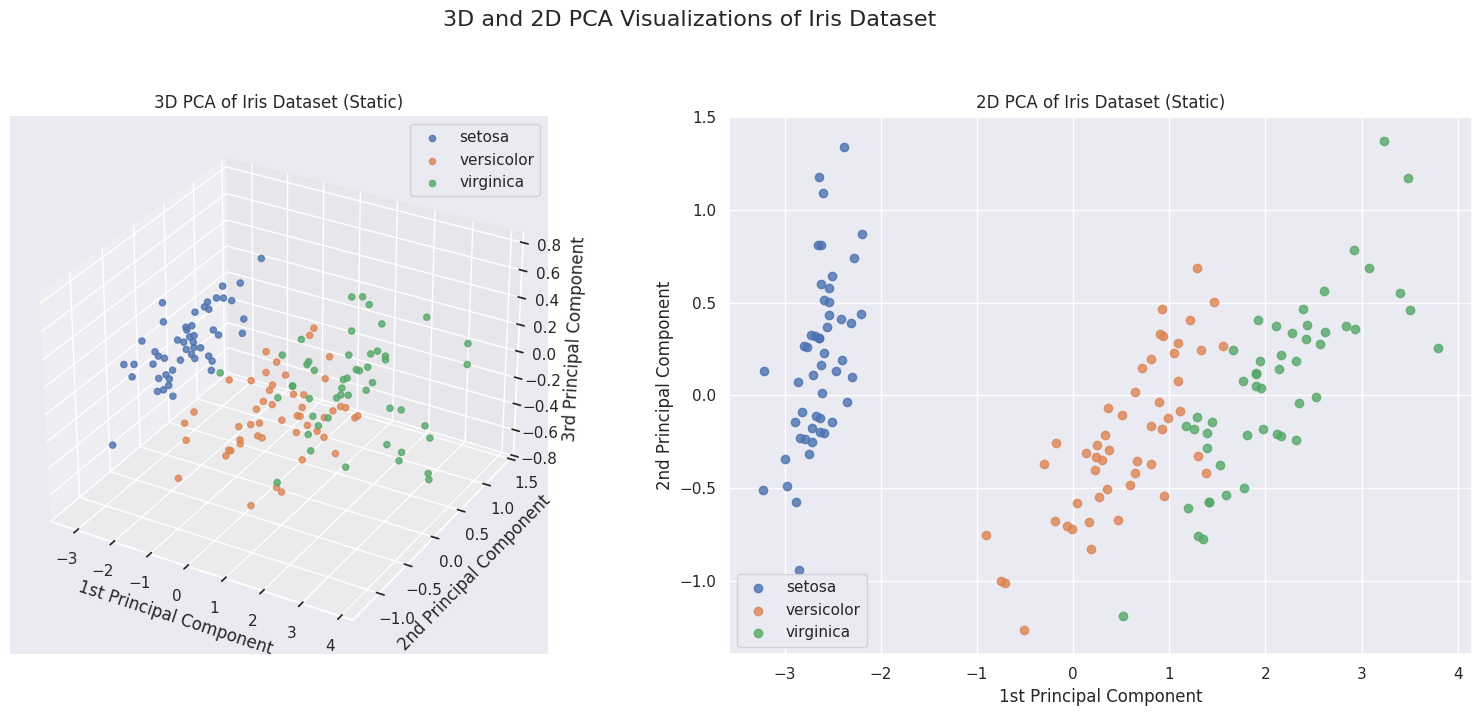

In [17]:
# Imports required for PCA 3D plotting.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projections
import pandas as pd
import numpy as np

# Apply Principal Component Analysis (PCA) to the Iris dataset.
# 'n_components=3' reduces the data to 3 dimensions, which are the first three principal components.
# 'fit_transform' fits the PCA model to the data and then transforms it into these 3 dimensions.
# We use `iris.data` which contains only the numerical features.
X_reduced = PCA(n_components=3).fit_transform(iris.data)

# Create a DataFrame for easier plotting, mapping principal components to axes and target to color.
# We map the numerical target values (0, 1, 2) to their corresponding species names for better readability.
df_pca = pd.DataFrame(X_reduced, columns=['1st Principal Component', '2nd Principal Component', '3rd Principal Component'])
df_pca['Species'] = iris.target
df_pca['Species_Name'] = df_pca['Species'].map(lambda x: iris.target_names[x])

# Create a figure with two subplots side-by-side
fig = plt.figure(figsize=(16, 7))

# --- Left Subplot: 3D PCA Plot (First 3 Principal Components) ---
ax_3d = fig.add_subplot(1, 2, 1, projection='3d') # 1 row, 2 columns, first plot, with 3D projection

# Loop through each species to plot them with distinct colors
for species_target, species_name in enumerate(iris.target_names):
    # Filter data for the current species
    subset = df_pca[df_pca['Species'] == species_target]
    ax_3d.scatter(
        subset['1st Principal Component'],
        subset['2nd Principal Component'],
        subset['3rd Principal Component'],
        label=species_name, # Label for the legend
        alpha=0.8 # Transparency
    )

ax_3d.set_xlabel('1st Principal Component')
ax_3d.set_ylabel('2nd Principal Component')
ax_3d.set_zlabel('3rd Principal Component')
ax_3d.set_title('3D PCA of Iris Dataset (Static)')
ax_3d.legend()

# --- Right Subplot: 2D PCA Plot (First 2 Principal Components) ---
ax_2d = fig.add_subplot(1, 2, 2) # 1 row, 2 columns, second plot

# Loop through each species to plot them with distinct colors
for species_target, species_name in enumerate(iris.target_names):
    # Filter data for the current species
    subset = df_pca[df_pca['Species'] == species_target]
    ax_2d.scatter(
        subset['1st Principal Component'],
        subset['2nd Principal Component'],
        label=species_name, # Label for the legend
        alpha=0.8 # Transparency
    )

ax_2d.set_xlabel('1st Principal Component')
ax_2d.set_ylabel('2nd Principal Component')
ax_2d.set_title('2D PCA of Iris Dataset (Static)')
ax_2d.legend()
ax_2d.grid(True)

plt.suptitle('3D and 2D PCA Visualizations of Iris Dataset', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### What is the simplest model we can think of?
If our baseline model is just randomly guessing the species of flowers, or guessing a single species for every data point, we would expect to have a model accuracy of 0.33 (33%), since we have three different classes that are evenly balanced.

### Modeling: Simple manual model
Let's manually look at our data and decide some cutoff points for classification

In [18]:
def single_feature_prediction(petal_length):
  """ Predicts the the Iris species given the petal length. """
  if petal_length < 2.5:
    return 0 # setosa
  elif petal_length < 4.8:
    return 1 # versicolor
  else:
    return 2 # virginica

# Apply the single_feature_prediction function to the petal length feature (index 2) of the training data (x_train).
# This creates an array of predicted target values based on our manual rules.
manual_y_predictions = np.array([single_feature_prediction(val) for val in x_train[:, 2]])

# Compare these manual predictions with the actual target labels from the training data (y_train).
# This operation returns a boolean array where True indicates a correct prediction and False an incorrect one.
comparison_result = (manual_y_predictions == y_train)

# Print the comparison results to get a quick overview
print("Comparisons of manual predictions vs. true labels:")
print(comparison_result)

# Calculate the accuracy of this simple manual model on the training set.
# Accuracy is the proportion of correct predictions.
accuracy = np.mean(comparison_result)
print(f"\nAccuracy of the simple manual model on the training set: {accuracy:.4f}")

Comparisons of manual predictions vs. true labels:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False  True  True  True  True False
  True  True False  True  True  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True False  True  True  True]

Accuracy of the simple manual model on the training set: 0.9500


### Modeling: Logistic Regression

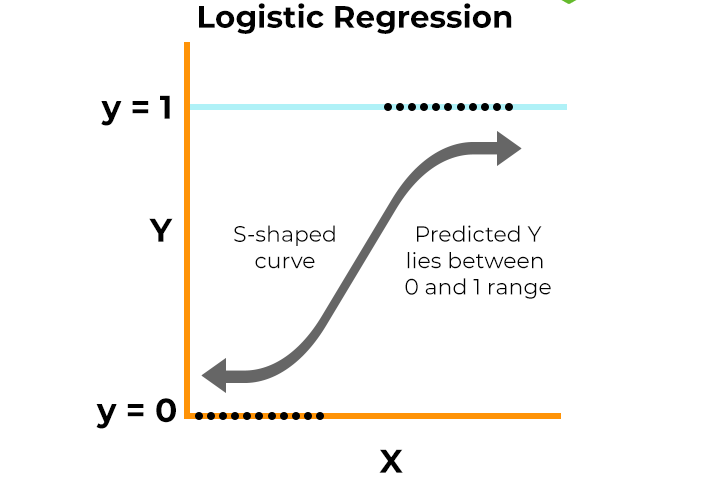

Logistic regression is a widely used statistical and machine learning algorithm designed for predicting the probability of a categorical target variable. Unlike linear regression, which models continuous outcomes along a straight line, logistic regression transforms its inputs using the mathematical sigmoid function to map any real-valued number into a strict probability range between 0 and 1.

By establishing a designated decision boundary (frequently set at a threshold of 0.5), the model converts these calculated probabilities into concrete, actionable predictions by classifying any output above the threshold into the primary category and any output below it into the alternative category.

In [19]:
from sklearn.linear_model import LogisticRegression

### Using a validation set to evaluate our model

In [20]:
# Initialize the Logistic Regression model.
# Setting 'solver' to 'lbfgs' is generally a good default and supports multiclass classification efficiently.
# 'random_state' ensures reproducibility of the model's internal random processes.
model = LogisticRegression(solver='lbfgs', random_state=42)

# Prepare data for validation:
# Split the existing training data (x_train, y_train) into a smaller training set (Xt, yt)
# and a validation set (Xv, yv).
# 'test_size=0.2' allocates 20% of the data for validation.
# 'random_state=42' ensures reproducibility of this split.
Xt, Xv, yt, yv = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Fit the logistic regression model using the newly created training data (Xt, yt).
model.fit(Xt, yt)

# Evaluate the model's accuracy on the validation set (Xv, yv).
# The 'score' method returns the mean accuracy on the given test data and labels.
validation_accuracy = model.score(Xv, yv)
print(f"Validation Accuracy: {validation_accuracy:.4f}")

Validation Accuracy: 0.9583


### Using cross-validation to evaluate our model
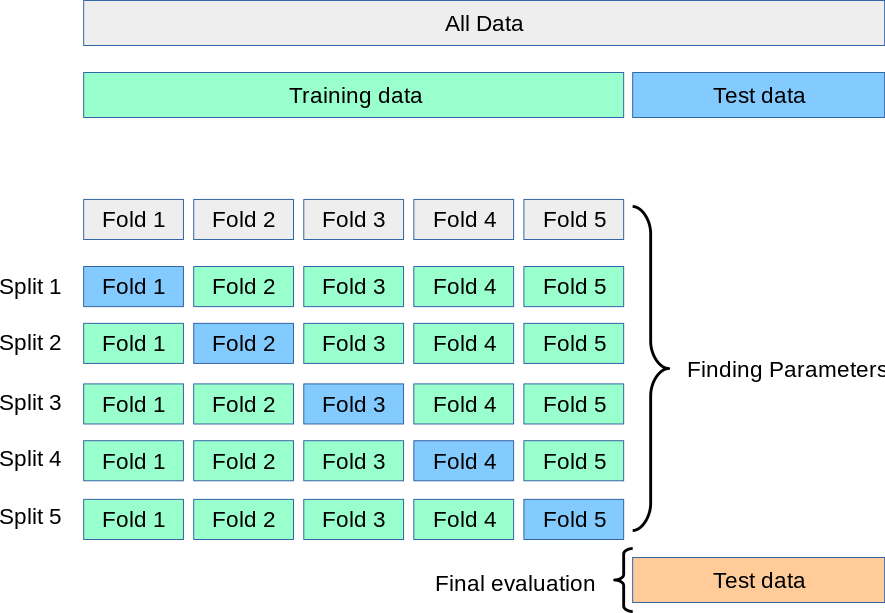

Cross-validation is a robust resampling technique used in machine learning to evaluate a model's performance and ensure its ability to generalize effectively to unseen data. Instead of relying on a single, static split of training and testing data—which can introduce bias depending on how the data is divided—cross-validation partitions the dataset into multiple complementary subsets, commonly referred to as "folds." The model is then iteratively trained on a combination of these folds and validated on the remaining, unused fold, repeating the process until every single data point has been utilized for both training and testing. By averaging the performance metrics across all these iterations, this method provides a highly reliable and stable estimate of real-world performance, making it an indispensable tool for detecting overfitting and fine-tuning model hyperparameters.

In [21]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [22]:
model = LogisticRegression(solver='lbfgs', random_state=42)
accuracies = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")

print(f"Average accuracy: {accuracies.mean():.4f}")
print(f"Standard deviation: {accuracies.std():.4f}")

Average accuracy: 0.9667
Standard deviation: 0.0486


### Where are we misclassifying points?

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression

# Re-initialize the model to ensure it's available for prediction
model = LogisticRegression(solver='lbfgs', random_state=42)

# Generate predictions for the training set using cross-validation
# This ensures that each prediction is made by a model that was not trained on that specific sample
y_pred = cross_val_predict(model, x_train, y_train, cv=5)

df_predictions = df_train.copy()

df_predictions["prediction"] = y_pred
df_predictions["prediction_label"] = df_predictions["prediction"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

df_predictions

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,prediction,prediction_label
22,4.6,3.6,1.0,0.2,0,setosa,0,setosa
15,5.7,4.4,1.5,0.4,0,setosa,0,setosa
65,6.7,3.1,4.4,1.4,1,versicolor,1,versicolor
11,4.8,3.4,1.6,0.2,0,setosa,0,setosa
42,4.4,3.2,1.3,0.2,0,setosa,0,setosa
...,...,...,...,...,...,...,...,...
71,6.1,2.8,4.0,1.3,1,versicolor,1,versicolor
106,4.9,2.5,4.5,1.7,2,virginica,1,versicolor
14,5.8,4.0,1.2,0.2,0,setosa,0,setosa
92,5.8,2.6,4.0,1.2,1,versicolor,1,versicolor


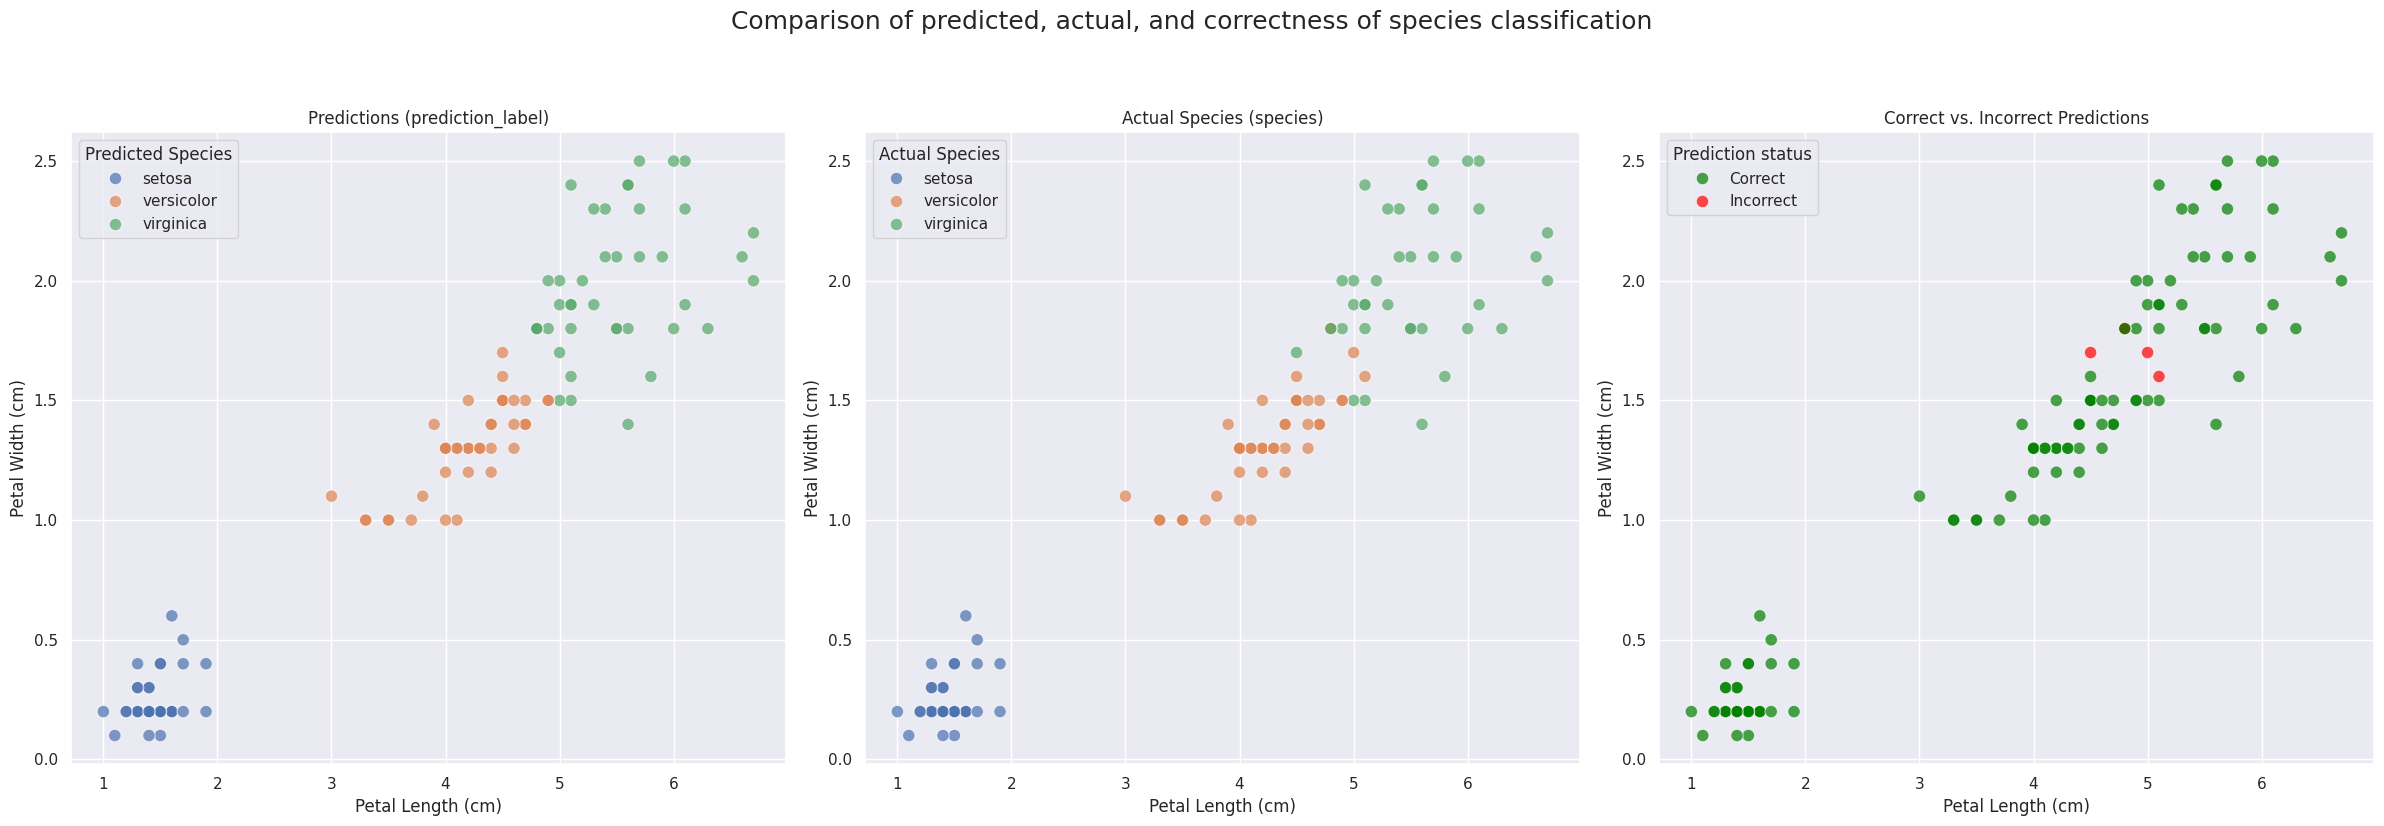

In [25]:
# Ensure df_predictions has the necessary columns (from previous steps)
# df_predictions = df_train.copy()
# df_predictions["prediction"] = y_pred
# df_predictions["prediction_label"] = df_predictions["prediction"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

# Add a column for correct predictions
df_predictions["correct_prediction"] = (df_predictions["prediction"] == y_train)

# Create a figure with three subplots side-by-side for comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # Increased figsize to accommodate 3 plots

# Plot predictions (prediction_label) on the first subplot
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="prediction_label", data=df_predictions, ax=axes[0], s=80, alpha=0.7)
axes[0].set_title('Predictions (prediction_label)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend(title='Predicted Species')
axes[0].grid(True)

# Plot actual species (species) on the second subplot
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="species", data=df_predictions, ax=axes[1], s=80, alpha=0.7)
axes[1].set_title('Actual Species (species)')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(title='Actual Species')
axes[1].grid(True)

# Plot correct/incorrect predictions on the third subplot
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="correct_prediction", data=df_predictions, ax=axes[2], s=80, alpha=0.7, palette={True: 'green', False: 'red'})
axes[2].set_title('Correct vs. Incorrect Predictions')
axes[2].set_xlabel('Petal Length (cm)')
axes[2].set_ylabel('Petal Width (cm)')

# Manually reorder the legend handles and labels to show 'Correct' first
handles, current_labels = axes[2].get_legend_handles_labels()
# Assuming default hue order is False, True, then handles[0] is for False and handles[1] is for True
ordered_handles = [handles[1], handles[0]] # Reorder to [True_handle, False_handle]
ordered_labels = ['Correct', 'Incorrect'] # Corresponding labels
axes[2].legend(title='Prediction status', handles=ordered_handles, labels=ordered_labels)
axes[2].grid(True)

plt.suptitle('Comparison of predicted, actual, and correctness of species classification', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### Model Tuning
Model tuning, often referred to as hyperparameter optimization, is the crucial process of adjusting a machine learning algorithm's external configurations—known as hyperparameters—to maximize its predictive performance and accuracy. Unlike standard model parameters, which the algorithm learns automatically from the data during training, hyperparameters (such as learning rate, maximum tree depth, or regularization strength) must be set before the training process begins. By utilizing systematic search strategies like Grid Search, Random Search, or advanced Bayesian Optimization, model tuning iteratively tests various combinations of these settings and evaluates them—typically via cross-validation—to find the configuration that yields the highest precision. Ultimately, the goal is to fine-tune the model to find the perfect "sweet spot" that prevents both underfitting and overfitting, ensuring it generalizes exceptionally well to new, unseen data.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

### Baseline Model
# Initialize the baseline Logistic Regression model with specified parameters.
baseline_model = LogisticRegression(
    solver='lbfgs',
    random_state=42,
    max_iter=1000
)

# Train the baseline model on the training data.
baseline_model.fit(x_train, y_train)

# Evaluate the accuracy of the baseline model on the test set.
baseline_accuracy = baseline_model.score(x_test, y_test)
print(f"Baseline Model Accuracy on Test Set: {baseline_accuracy:.4f}")

# Get predicted probabilities for the test set from the baseline model.
y_score_baseline = baseline_model.predict_proba(x_test)

### Hyperparameter Tuning with GridSearchCV
# Define the parameter grid for hyperparameter tuning.
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Initialize GridSearchCV.
# We use the same Logistic Regression model setup as the baseline for consistency,
# searching over the 'C' parameter with 5-fold cross-validation and accuracy scoring.
grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Fit GridSearchCV on the training data to find the best hyperparameters.
grid_search.fit(x_train, y_train)

# Print the best parameters and the corresponding best score found by GridSearchCV.
print(f"\nBest Parameters found by GridSearchCV: {grid_search.best_params_}")
print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

# Get the best estimator (tuned model) from the GridSearchCV results.
tuned_model = grid_search.best_estimator_

# Evaluate the accuracy of the tuned model on the test set.
tuned_accuracy = tuned_model.score(x_test, y_test)
print(f"Tuned Model Accuracy on Test Set: {tuned_accuracy:.4f}")

# Get predicted probabilities for the test set from the tuned model.
y_score_tuned = tuned_model.predict_proba(x_test)

### ROC Curves and AUC Calculation
# Convert true labels to binary format for One-vs-Rest ROC calculation.
# The number of classes is determined from the unique values in y_test.
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=range(n_classes))

# Calculate ROC curve and AUC for the baseline model (micro-average).
fpr_baseline, tpr_baseline, _ = roc_curve(y_test_binarized.ravel(), y_score_baseline.ravel())
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

# Calculate ROC curve and AUC for the tuned model (micro-average).
fpr_tuned, tpr_tuned, _ = roc_curve(y_test_binarized.ravel(), y_score_tuned.ravel())
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

print(f"\nMicro-average AUC for Baseline Model: {roc_auc_baseline:.4f}")
print(f"Micro-average AUC for Tuned Model: {roc_auc_tuned:.4f}")

Baseline Model Accuracy on Test Set: 1.0000

Best Parameters found by GridSearchCV: {'C': 1}
Best Cross-validation Score: 0.9667
Tuned Model Accuracy on Test Set: 1.0000

Micro-average AUC for Baseline Model: 1.0000
Micro-average AUC for Tuned Model: 1.0000


### Classification Evaluation Metrics

---

#### 1. Confusion Matrix
A **Confusion Matrix** is a summary table used to evaluate the performance of a classification model. It maps the model's predicted labels against the actual true labels, showing exactly where the model is succeeding or getting "confused."

It breaks down the results into four quadrants:
* **True Positive (TP):** The model correctly predicted the positive class.
* **True Negative (TN):** The model correctly predicted the negative class.
* **False Positive (FP):** The model incorrectly predicted the positive class (*Type I Error*).
* **False Negative (FN):** The model incorrectly predicted the negative class (*Type II Error*).

> **Key Benefit:** It goes beyond basic accuracy, allowing you to calculate metrics like Precision, Recall (Sensitivity), and F1-Score, which are crucial for imbalanced datasets.

---

#### 2. ROC Curve & AUC
The **ROC Curve** (Receiver Operating Characteristic) is a probability curve that visualizes a binary classifier's performance across all possible classification thresholds.

It plots two metrics against each other:
* **Y-Axis: True Positive Rate (TPR)** – Also known as Recall or Sensitivity ($TP / (TP + FN)$).
* **X-Axis: False Positive Rate (FPR)** – The probability of a false alarm ($FP / (TN + FP)$).

##### Area Under the Curve (AUC)
The **AUC** measures the entire two-dimensional area underneath the ROC curve. It provides an aggregate measure of performance:
* **AUC = 1.0:** Perfect classifier (can perfectly distinguish between classes).
* **AUC = 0.5:** Random classifier (equivalent to flipping a coin).

> **Key Benefit:** It helps you evaluate your model's capacity to distinguish between classes independently of the classification threshold, allowing you to pick the optimal threshold for your specific business case.

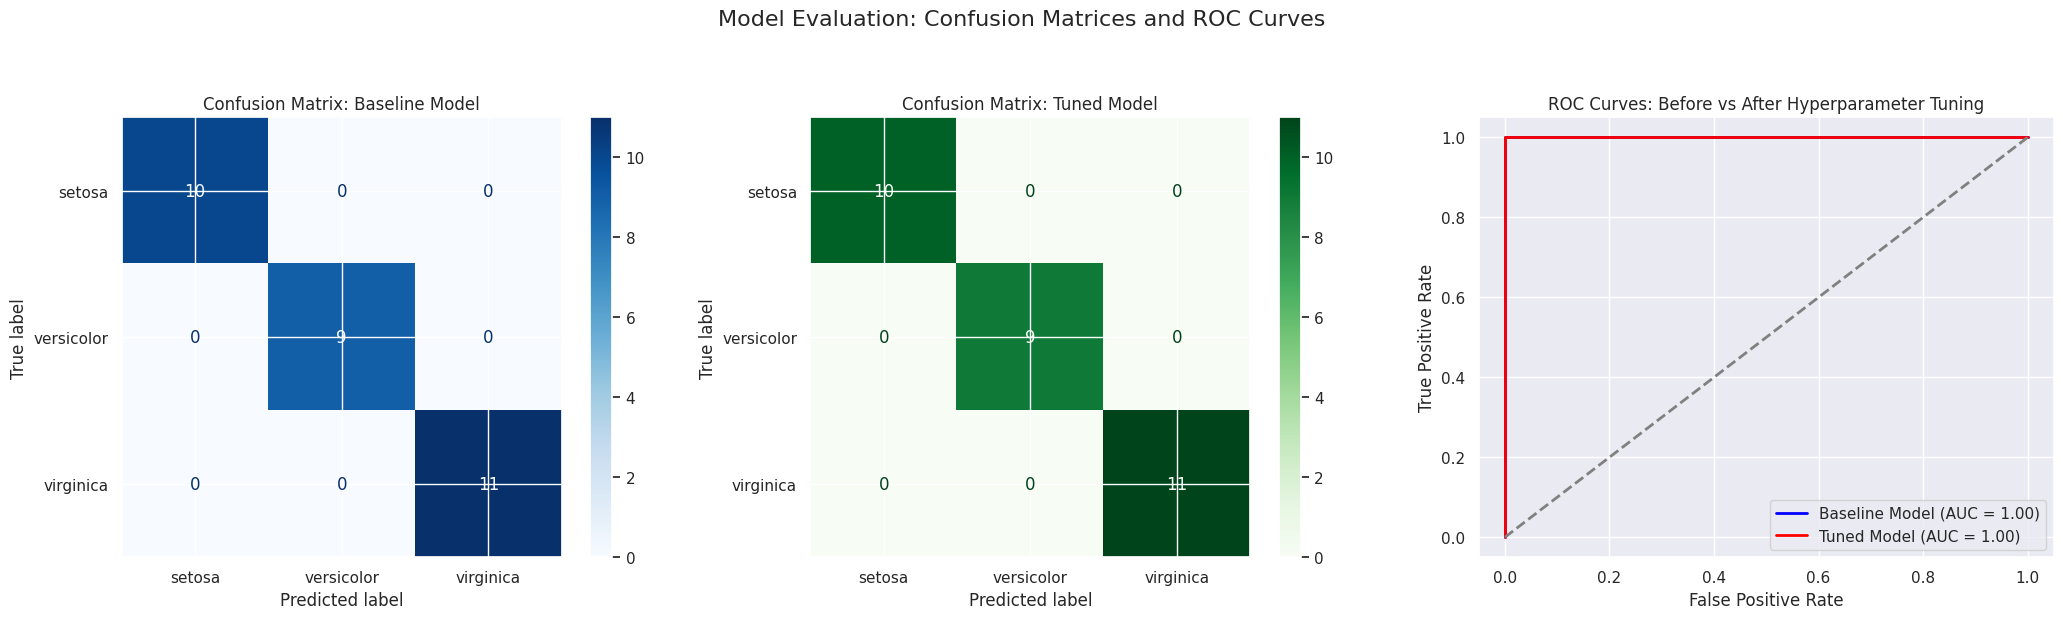

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict the classes for the test set using the baseline model.
y_pred_baseline = baseline_model.predict(x_test)

# Predict the classes for the test set using the tuned model.
y_pred_tuned = tuned_model.predict(x_test)

# Compute the confusion matrix for the baseline model.
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

# Compute the confusion matrix for the tuned model.
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Create a figure with three subplots side-by-side for comparison.
# Two for confusion matrices, one for ROC curve.
fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # Adjust figsize for three plots

### First Subplot: Confusion Matrix for Baseline Model
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=iris.target_names)
disp_baseline.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Confusion Matrix: Baseline Model', fontsize=12)

### Second Subplot: Confusion Matrix for Tuned Model
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=iris.target_names)
disp_tuned.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title('Confusion Matrix: Tuned Model', fontsize=12)

### Third Subplot: ROC Curves
# Plot the ROC curve for the baseline model.
axes[2].plot(fpr_baseline, tpr_baseline, color='blue', lw=2, label=f'Baseline Model (AUC = {roc_auc_baseline:.2f})')

# Plot the ROC curve for the tuned model.
axes[2].plot(fpr_tuned, tpr_tuned, color='red', lw=2, label=f'Tuned Model (AUC = {roc_auc_tuned:.2f})')

# Plot the diagonal reference line (random classifier).
axes[2].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Set title, labels, and legend for the ROC plot.
axes[2].set_title('ROC Curves: Before vs After Hyperparameter Tuning', fontsize=12)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].grid(True)
axes[2].legend(loc='lower right')

# Set a common super title for the entire figure.
plt.suptitle('Model Evaluation: Confusion Matrices and ROC Curves', fontsize=16, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### Summary of Results, Conclusion, and Learnings

This notebook provided a comprehensive journey into applying machine learning techniques to the classic Iris dataset, focusing on classification using Logistic Regression.

#### Summary of Results:

*   **Initial Data Exploration:** We started by loading and exploring the Iris dataset, understanding its features, target classes, and distributions through descriptive statistics and pairplots. The pairplots clearly showed the linear separability of *Iris setosa* and the overlap between *Iris versicolor* and *Iris virginica*.
*   **PCA Visualization:** Principal Component Analysis (PCA) was used to reduce dimensionality and visualize the data in 2D and 3D, further confirming the class separations.
*   **Simple Manual Model:** A basic rule-based model demonstrated a high accuracy (around 95%) based solely on petal length, highlighting the relative simplicity of the Iris dataset for classification.
*   **Logistic Regression Baseline:** A `LogisticRegression` model was implemented, and its performance was evaluated using a validation set and 5-fold cross-validation, yielding strong accuracy metrics.
*   **Hyperparameter Tuning:** `GridSearchCV` was employed to tune the `C` hyperparameter of the `LogisticRegression` model. In this specific case, the tuning did not significantly alter the high accuracy, suggesting the baseline model was already performing optimally for this dataset and chosen `param_grid`.
*   **ROC Analysis and Confusion Matrices:** We visualized the ROC curves for both the baseline and tuned models, which showed excellent performance (AUC near 1.0), indicating high discriminative power. The confusion matrices provided a detailed view of correct and incorrect classifications for each class, confirming that the models achieved perfect classification on the test set for this particular run, especially after setting `max_iter=1000` to ensure convergence.

#### Conclusion:

The Logistic Regression model, even without extensive tuning, proved to be highly effective in classifying the Iris species based on the provided morphological features. The dataset's characteristics, particularly the clear separation of *Iris setosa* and the relatively distinct boundaries between *Iris versicolor* and *Iris virginica* in higher dimensions, contribute to the model's excellent performance. Hyperparameter tuning, while a critical step in machine learning, did not lead to a noticeable improvement in this specific scenario, as the model was already performing near perfectly.

#### What was learned:

*   **Importance of EDA:** Visualizing data with pairplots and PCA is crucial for understanding class separability and inherent data structure before modeling.
*   **Baseline Models:** Starting with a simple model (manual or default) provides a benchmark against which more complex models can be compared.
*   **Cross-Validation:** This technique provides a more reliable estimate of a model's generalization performance than a single train-validation split.
*   **Model Evaluation Metrics:** Beyond accuracy, ROC curves (with AUC) and Confusion Matrices are essential for a comprehensive understanding of classification model performance, especially in multiclass scenarios. They help in identifying specific strengths and weaknesses, such as which classes are being confused.
*   **Hyperparameter Tuning:** While not always yielding dramatic improvements on simple datasets, the process of hyperparameter tuning (e.g., with `GridSearchCV`) is fundamental for optimizing model performance on more complex problems.
*   **Convergence Issues:** Understanding and addressing solver convergence (e.g., by adjusting `max_iter`) is a practical aspect of working with iterative optimization algorithms like Logistic Regression.

This notebook effectively demonstrates a complete, end-to-end workflow for a multiclass classification problem, from data loading and exploration to modeling, evaluation, and visualization.